# EduPredict EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Importing data

In [2]:
csv_path = "../data/raw/dataset-6ab002b01f9ef078223946.csv"

df = pd.read_csv(csv_path)

# 2. General overview

In [3]:
df.head()
df.tail()
df.columns.tolist()
df.info()
df.describe()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

(6607, 20)

## 3. Missing values

In [4]:
df.isna().sum().sort_values(ascending=False).head()

Parental_Education_Level    90
Teacher_Quality             78
Distance_from_Home          67
Hours_Studied                0
Access_to_Resources          0
dtype: int64

## 4. Duplicated values

In [5]:
df.duplicated().sum()

np.int64(0)

## 5. Descriptive stats

In [6]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,NaN,NaN,NaN,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,NaN,NaN,NaN,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Parental_Involvement,6607,3,Medium,3362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Access_to_Resources,6607,3,Medium,3319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Extracurricular_Activities,6607,2,Yes,3938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep_Hours,6607.0,NaN,NaN,NaN,7.02906,1.46812,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,NaN,NaN,NaN,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Motivation_Level,6607,3,Medium,3351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Internet_Access,6607,2,Yes,6108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tutoring_Sessions,6607.0,NaN,NaN,NaN,1.493719,1.23057,0.0,1.0,1.0,2.0,8.0


## 6. Time validation

In [7]:
parsed = pd.to_datetime(df['Hours_Studied'], errors='coerce')
bad = df['Hours_Studied'][parsed.isna() & df['Hours_Studied'].notna()]
print(len(bad))

0


## 7.Numeric checks

In [8]:
numeric_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

for col in numeric_cols:
    negative_val = df[df[col] < 0]

    if not negative_val.empty:
        print(negative_val)



## 8.Unique categories

In [9]:
known_cols = ['Gender',"School_Type",'Extracurricular_Activities','Internet_Access','Learning_Disabilities','Peer_Influence']

for col in known_cols:
    print(df[col].unique())


<StringArray>
['Male', 'Female']
Length: 2, dtype: str
<StringArray>
['Public', 'Private']
Length: 2, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
<StringArray>
['Positive', 'Negative', 'Neutral']
Length: 3, dtype: str


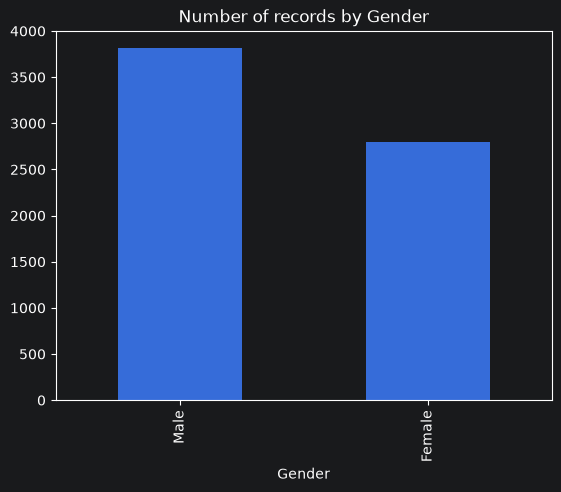

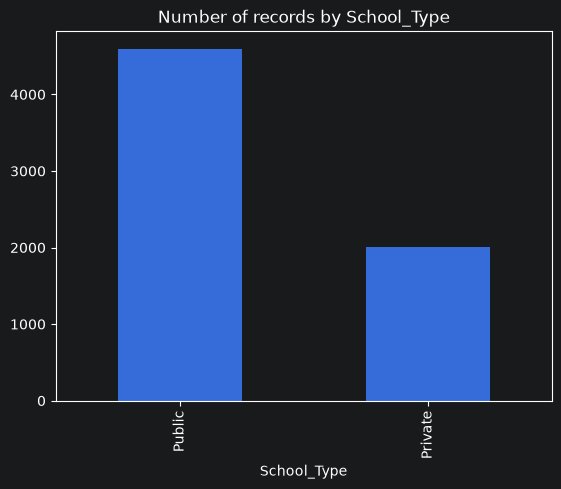

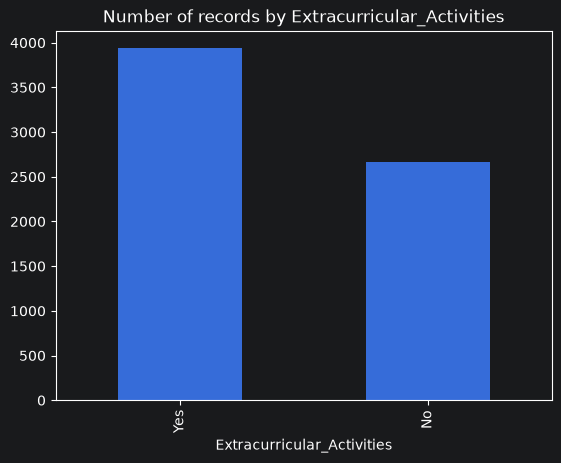

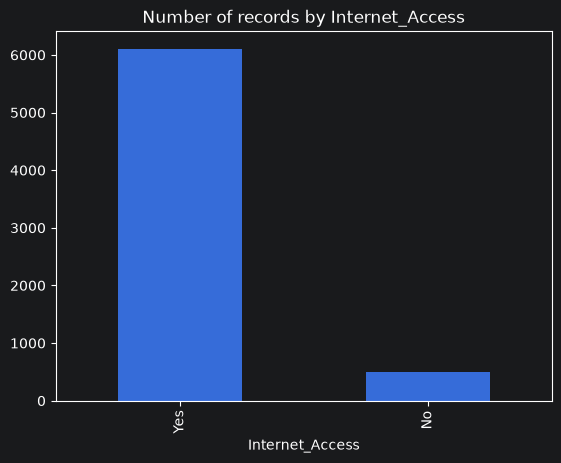

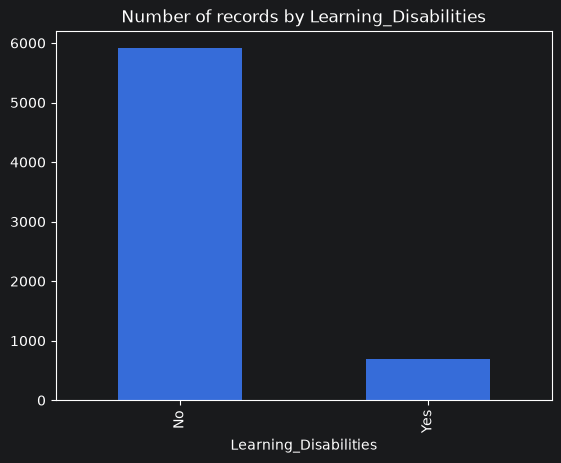

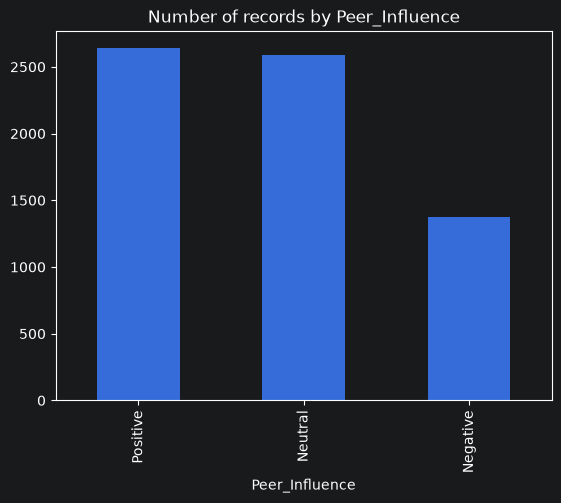

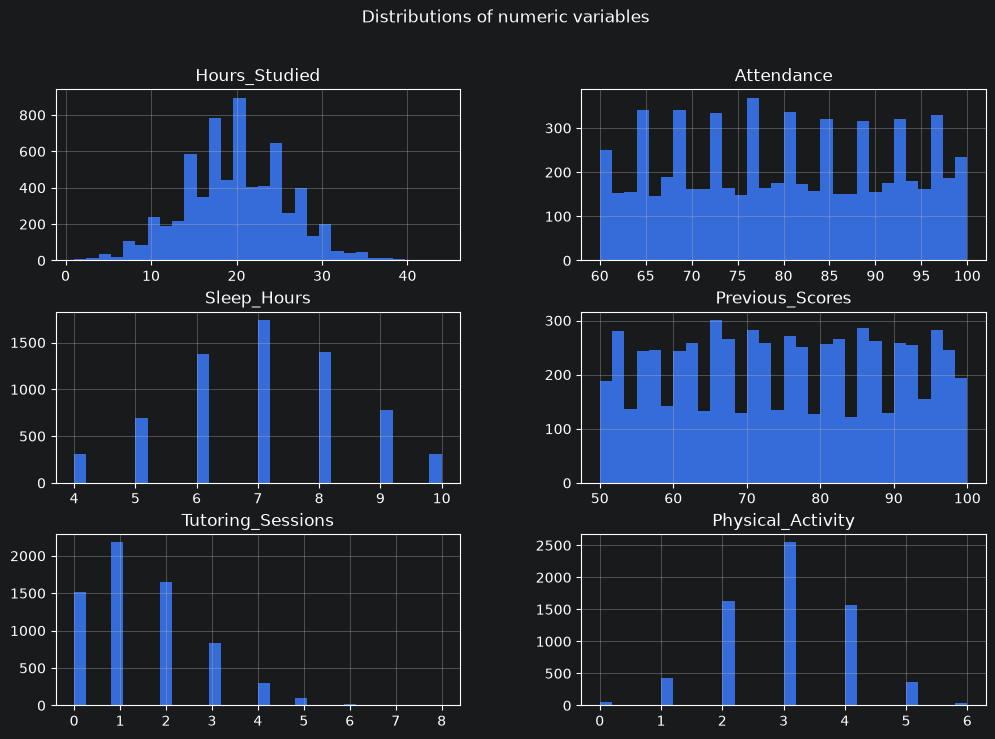

In [10]:
categorical_columns = ['Gender',"School_Type",'Extracurricular_Activities','Internet_Access','Learning_Disabilities','Peer_Influence']
for column in categorical_columns:
    df[column].value_counts(dropna=False).plot(kind='bar')
    plt.title(f'Number of records by {column}')
    plt.show()

numeric_columns = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
df[numeric_columns].hist(figsize=(12, 8), bins=30)
plt.suptitle('Distributions of numeric variables')
plt.show()




## 9.Feature relationships

,Previous_Scores,Exam_Score
Gender,,
Male,75.083115,67.228894
Female,75.053348,67.244898


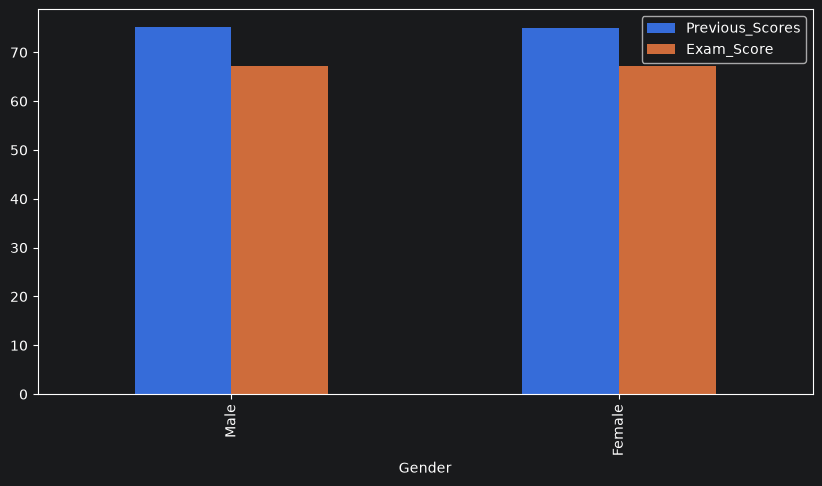

,Previous_Scores,Exam_Score
School_Type,,
Public,75.198565,67.212919
Private,74.777501,67.287705


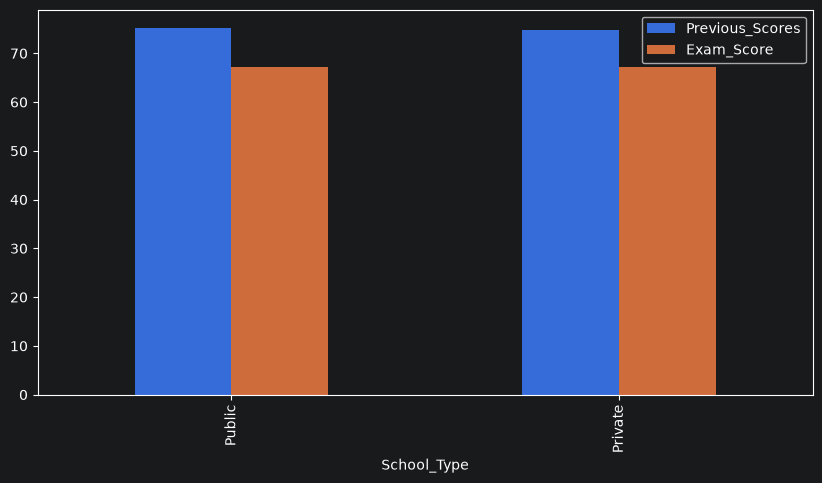

,Previous_Scores,Exam_Score
Extracurricular_Activities,,
Yes,75.122143,67.441849
No,74.994380,66.931435


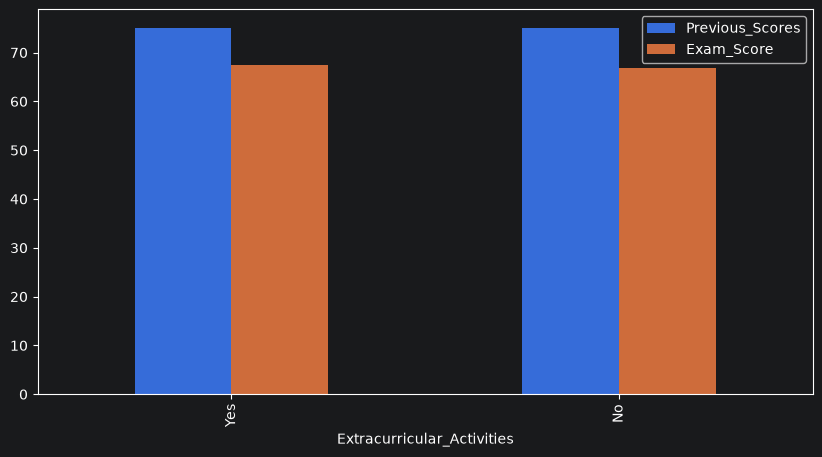

,Previous_Scores,Exam_Score
Internet_Access,,
Yes,75.088245,67.292895
No,74.853707,66.535070


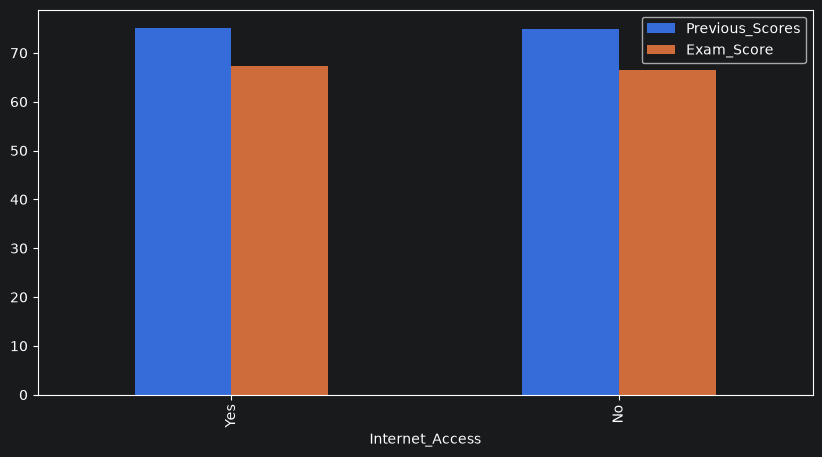

,Previous_Scores,Exam_Score
Learning_Disabilities,,
Yes,75.366906,66.270504
No,75.035690,67.349120


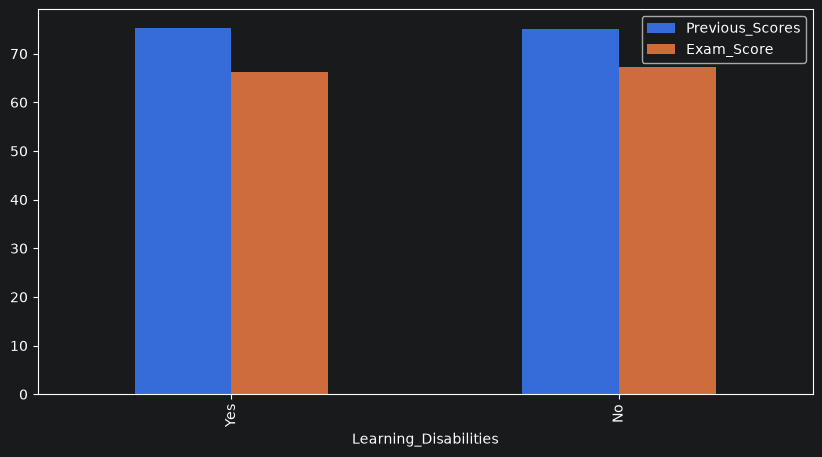

,Previous_Scores,Exam_Score
Peer_Influence,,
Neutral,75.391204,67.197917
Negative,75.238199,66.564270
Positive,74.667930,67.623199


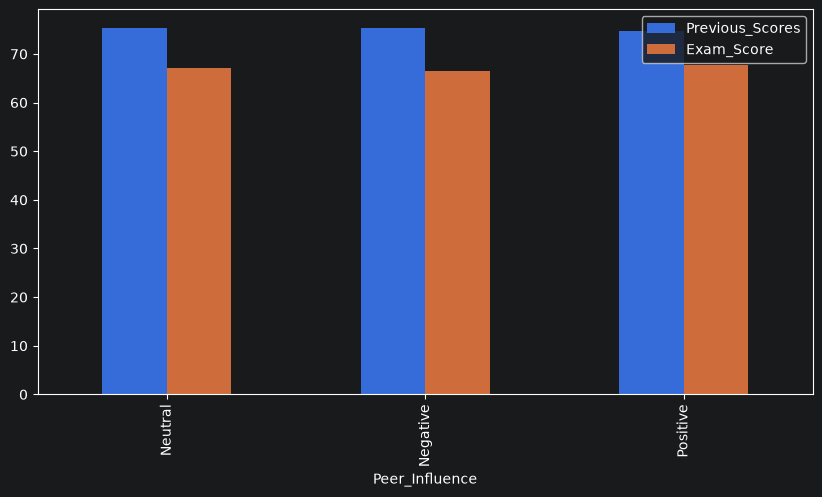

In [11]:
for col in categorical_columns:
    category_summary = df.groupby(col)[['Previous_Scores', 'Exam_Score']].mean().sort_values('Previous_Scores', ascending=False)
    display(category_summary)
    category_summary.plot(kind='bar', figsize=(10, 5))
    plt.show()


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity
Hours_Studied,1.000000,-0.009908,0.010977,0.024846,-0.014282,0.004624
Attendance,-0.009908,1.000000,-0.015918,-0.020186,0.014324,-0.022435
Sleep_Hours,0.010977,-0.015918,1.000000,-0.021750,-0.012216,-0.000378
Previous_Scores,0.024846,-0.020186,-0.021750,1.000000,-0.013122,-0.011274
Tutoring_Sessions,-0.014282,0.014324,-0.012216,-0.013122,1.000000,0.017733
Physical_Activity,0.004624,-0.022435,-0.000378,-0.011274,0.017733,1.000000


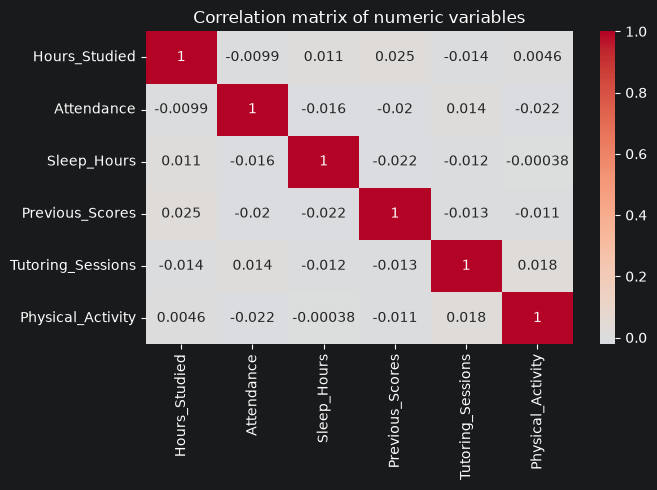

In [12]:
corr_matrix = df[numeric_columns].corr()
display(corr_matrix)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation matrix of numeric variables')
plt.tight_layout()
plt.show()
